# Phase 6: Advanced Models — CatBoost & TabM

Extends the Phase 2 baselines with two modern tabular methods, evaluated with the
**same 5-fold Stratified CV** for a fair comparison.

- **CatBoost** — gradient boosting on oblivious trees, using ordered boosting and
  ordered target statistics to fight target leakage. Paper: https://arxiv.org/abs/1706.09516
- **TabM** — an MLP with parameter-efficient (BatchEnsemble) ensembling: one shared
  weight matrix plus per-member rank-1 adapters simulate `k` MLPs. Implemented from
  scratch in PyTorch. Paper: https://arxiv.org/abs/2410.24210


In [1]:
%pip install catboost torch scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\NDHoang\PycharmProjects\ML-_Project_Autism_Prediction\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
# Install if needed:
# %pip install catboost torch scikit-learn matplotlib

import warnings, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, RocCurveDisplay

import torch
import torch.nn as nn

from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.1+cpu | device: cpu


## Step 0: Read the cleaned data

In [3]:
from pathlib import Path

DATA_DIR = Path("../data/processed")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/processed")

train = pd.read_csv(DATA_DIR / "train_cleaned.csv")
test = pd.read_csv(DATA_DIR / "test_cleaned.csv")

TARGET = "Class/ASD"
X = train.drop(columns=[TARGET])
y = train[TARGET]

# Same CV as Phase 2 so the leaderboard is comparable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X_np, y_np = X.values.astype(np.float32), y.values.astype(np.int64)
print(f"train: {X.shape} | classes: {y.value_counts().to_dict()}")

leaderboard = []  # collect results from each model

train: (23743, 32) | classes: {1: 12436, 0: 11307}


### Step 1: CatBoost (5-fold Stratified CV)

`auto_class_weights="Balanced"` handles the class imbalance internally.

In [4]:
def cb_params():
    return dict(iterations=400, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
                loss_function="Logloss", eval_metric="AUC",
                auto_class_weights="Balanced", random_seed=SEED, verbose=False)

cb_auc, cb_f1, cb_acc = [], [], []
t0 = time.time()
for fold, (tr, va) in enumerate(cv.split(X_np, y_np), 1):
    model = CatBoostClassifier(**cb_params())
    model.fit(X_np[tr], y_np[tr])
    p = model.predict_proba(X_np[va])[:, 1]
    pred = (p >= 0.5).astype(int)
    cb_auc.append(roc_auc_score(y_np[va], p))
    cb_f1.append(f1_score(y_np[va], pred))
    cb_acc.append(accuracy_score(y_np[va], pred))
    print(f"  fold {fold}: AUC={cb_auc[-1]:.4f}")

print(f"\nCatBoost | AUC {np.mean(cb_auc):.4f} +/- {np.std(cb_auc):.4f} "
      f"| F1 {np.mean(cb_f1):.4f} | Acc {np.mean(cb_acc):.4f} | {time.time()-t0:.1f}s")

leaderboard.append({"Model": "CatBoost",
                    "Accuracy": np.mean(cb_acc), "Accuracy-Std": np.std(cb_acc),
                    "F1-Score": np.mean(cb_f1), "F1-Std": np.std(cb_f1),
                    "ROC-AUC": np.mean(cb_auc), "ROC-AUC-Std": np.std(cb_auc)})

  fold 1: AUC=0.9799


  fold 2: AUC=0.9790


  fold 3: AUC=0.9801


  fold 4: AUC=0.9795


  fold 5: AUC=0.9786

CatBoost | AUC 0.9794 +/- 0.0006 | F1 0.9237 | Acc 0.9207 | 15.8s


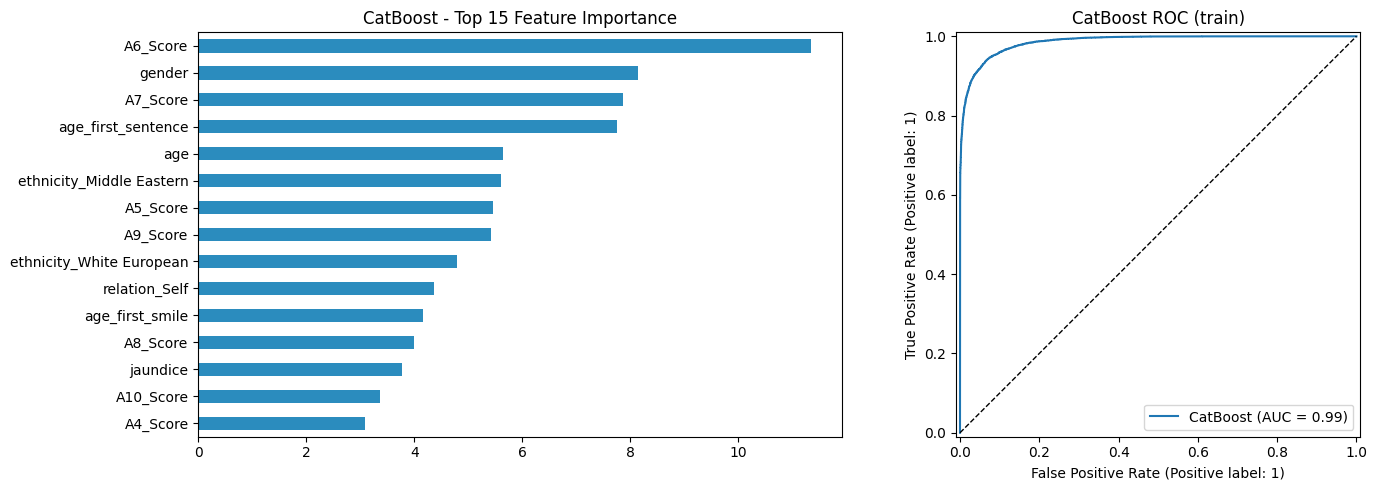

In [5]:
# Refit on all data for feature importance and ROC
cb_final = CatBoostClassifier(**cb_params()).fit(X_np, y_np)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
imp = pd.Series(cb_final.feature_importances_, index=X.columns).sort_values()
imp.tail(15).plot.barh(ax=ax[0], color="#2b8cbe")
ax[0].set_title("CatBoost - Top 15 Feature Importance")

RocCurveDisplay.from_predictions(y_np, cb_final.predict_proba(X_np)[:, 1], ax=ax[1], name="CatBoost")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_title("CatBoost ROC (train)")
plt.tight_layout()
plt.show()

### Step 2 (optional): SHAP for CatBoost

Ties into Phase 5 (Explainable AI). Runs only if `shap` is installed
(`%pip install shap`); otherwise it is skipped.

In [6]:
try:
    import shap
    explainer = shap.TreeExplainer(cb_final)
    sv = explainer.shap_values(X_np)
    shap.summary_plot(sv, X, plot_type="bar", show=True)
except Exception as e:
    print("Skipping SHAP:", e)

Skipping SHAP: No module named 'shap'


### Step 3: TabM (implemented from scratch in PyTorch)

`BatchEnsembleLinear` shares one weight matrix `W` and adds per-member rank-1
adapters `r, s`. Every input passes through all `k` members; predictions average
the softmax over members.

In [7]:
class BatchEnsembleLinear(nn.Module):
    """Shared weight W + per-member rank-1 adapters (r, s) -- BatchEnsemble."""
    def __init__(self, in_f, out_f, k):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_f, in_f))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        # random +/-1 init keeps the k members diverse
        self.r = nn.Parameter(torch.randint(0, 2, (k, in_f)).float() * 2 - 1)
        self.s = nn.Parameter(torch.randint(0, 2, (k, out_f)).float() * 2 - 1)
        self.bias = nn.Parameter(torch.zeros(k, out_f))

    def forward(self, x):                              # x: (B, k, in)
        x = x * self.r                                 # per-member input scaling
        x = torch.einsum("bki,oi->bko", x, self.weight)  # shared weight
        return x * self.s + self.bias                  # per-member output scaling + bias


class TabM(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=256, n_blocks=2, k=32, dropout=0.1):
        super().__init__()
        self.k = k
        dims = [n_features] + [hidden] * n_blocks
        self.layers = nn.ModuleList(
            [BatchEnsembleLinear(dims[i], dims[i + 1], k) for i in range(n_blocks)])
        self.drop = nn.Dropout(dropout)
        self.head = BatchEnsembleLinear(hidden, n_classes, k)

    def forward(self, x):                              # x: (B, features)
        x = x.unsqueeze(1).expand(-1, self.k, -1)      # replicate for k members
        for lyr in self.layers:
            x = self.drop(torch.relu(lyr(x)))
        return self.head(x)                            # (B, k, n_classes)

    @torch.no_grad()
    def predict_proba(self, x):                        # average softmax over members
        self.eval()
        return self(x).softmax(-1).mean(1)[:, 1].cpu().numpy()

In [8]:
def fit_tabm(Xtr, ytr, Xval, yval, k=32, epochs=300, patience=25, lr=1e-3, bs=256):
    """Train one TabM with early stopping on validation AUC. Returns model + scaler."""
    sc = StandardScaler().fit(Xtr)
    Xtr_t = torch.tensor(sc.transform(Xtr), dtype=torch.float32, device=DEVICE)
    Xval_t = torch.tensor(sc.transform(Xval), dtype=torch.float32, device=DEVICE)
    ytr_t = torch.tensor(ytr, device=DEVICE)

    model = TabM(Xtr.shape[1], k=k).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss()

    best_auc, best_state, wait, history = 0.0, None, 0, []
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr_t), device=DEVICE)
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            logits = model(Xtr_t[idx])                       # (b, k, C)
            b, kk, C = logits.shape
            loss = lossf(logits.reshape(b * kk, C), ytr_t[idx].repeat_interleave(kk))
            opt.zero_grad(); loss.backward(); opt.step()
        auc = roc_auc_score(yval, model.predict_proba(Xval_t))
        history.append(auc)
        if auc > best_auc:                                   # keep best weights
            best_auc, wait = auc, 0
            best_state = {n: p.detach().clone() for n, p in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, sc, best_auc, history


# 5-fold CV for TabM (inner split from each fold's train for early stopping)
tm_auc, tm_f1, tm_acc, last_history = [], [], [], None
t0 = time.time()
for fold, (tr, va) in enumerate(cv.split(X_np, y_np), 1):
    Xtr_in, Xes, ytr_in, yes = train_test_split(
        X_np[tr], y_np[tr], test_size=0.2, stratify=y_np[tr], random_state=SEED)
    model, sc, _, last_history = fit_tabm(Xtr_in, ytr_in, Xes, yes)
    Xva_t = torch.tensor(sc.transform(X_np[va]), dtype=torch.float32, device=DEVICE)
    p = model.predict_proba(Xva_t)
    pred = (p >= 0.5).astype(int)
    tm_auc.append(roc_auc_score(y_np[va], p))
    tm_f1.append(f1_score(y_np[va], pred))
    tm_acc.append(accuracy_score(y_np[va], pred))
    print(f"  fold {fold}: AUC={tm_auc[-1]:.4f}")

print(f"\nTabM | AUC {np.mean(tm_auc):.4f} +/- {np.std(tm_auc):.4f} "
      f"| F1 {np.mean(tm_f1):.4f} | Acc {np.mean(tm_acc):.4f} | {time.time()-t0:.1f}s")

leaderboard.append({"Model": "TabM",
                    "Accuracy": np.mean(tm_acc), "Accuracy-Std": np.std(tm_acc),
                    "F1-Score": np.mean(tm_f1), "F1-Std": np.std(tm_f1),
                    "ROC-AUC": np.mean(tm_auc), "ROC-AUC-Std": np.std(tm_auc)})

  fold 1: AUC=0.9799


  fold 2: AUC=0.9790


  fold 3: AUC=0.9808


  fold 4: AUC=0.9793


  fold 5: AUC=0.9787

TabM | AUC 0.9796 +/- 0.0007 | F1 0.9237 | Acc 0.9203 | 1637.2s


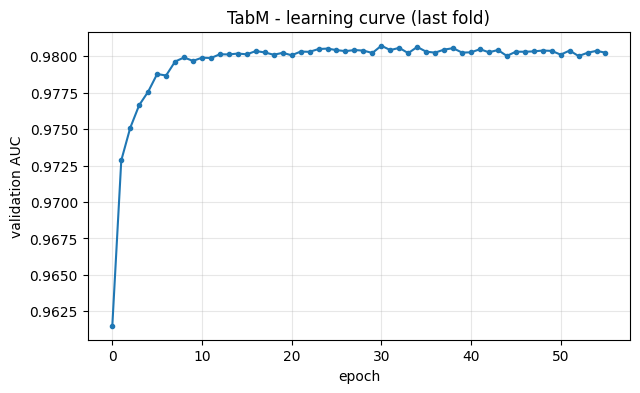

In [9]:
# Validation AUC per epoch (last fold) -- check convergence / overfitting
plt.figure(figsize=(7, 4))
plt.plot(last_history, marker=".")
plt.xlabel("epoch"); plt.ylabel("validation AUC")
plt.title("TabM - learning curve (last fold)")
plt.grid(alpha=.3)
plt.show()

### Step 4: Leaderboard

In [10]:
results_df = (pd.DataFrame(leaderboard).round(4)
              .sort_values("ROC-AUC", ascending=False).reset_index(drop=True))

print("\n--- LEADERBOARD ---")
display(results_df)


--- LEADERBOARD ---


,Model,Accuracy,Accuracy-Std,F1-Score,F1-Std,ROC-AUC,ROC-AUC-Std
0,TabM,0.9203,0.0031,0.9237,0.0030,0.9796,0.0007
1,CatBoost,0.9207,0.0031,0.9237,0.0028,0.9794,0.0006
